# Sahyadri Simulation — Getting Started Tutorial

This notebook is a short, hands-on introduction to reading and visualizing outputs
from the **Sahyadri** N-body dark matter simulation suite. It shows how to:

1. load a compressed particle **snapshot** (dark matter positions/velocities),
2. make a 2D slice plot of the particle field, and
3. load a **halo catalog** and overlay halos (colored by linear bias, sized by
   virial radius) on top of the dark matter.

Full data products, column definitions, and download tools are available at
[sahyadri.tifr.res.in](https://sahyadri.tifr.res.in).

> **New to the data?** Everything you need to run this notebook — including a
> small (1%) sample dataset — is fetched automatically in the setup cell below
> when running on Google Colab. If you're running locally with your own
> downloaded data, you can skip that cell.


[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/a-paranjape/sahyadri-sandbox/blob/sahyadri_webpage/sahyadri_webpage/resources/Sahyadri_read_particles.ipynb)

Click the badge above to open and run this notebook in Google Colab — no local
install required. (This links to the `sahyadri_webpage` branch, since that's
where the notebook currently lives; update the link once it lands on `main`.)


In [1]:
# ------------------------------------------------------------------
# Colab / environment setup
#
# This cell only does anything when running on Google Colab: it
#   1) installs the couple of packages Colab doesn't ship by default,
#   2) downloads the small helper module `read_snaps.py` that the rest of
#      this notebook imports, and
#   3) downloads a small 1% particle subsample + halo catalog for the
#      `default2048` simulation, using the same wget commands produced by
#      the download builder at https://sahyadri.tifr.res.in/data-products.html
#
# If you're running this locally and already have `read_snaps.py` and your
# own data on disk, it's safe to just skip/not run this cell.
# ------------------------------------------------------------------
import sys, os, subprocess

IN_COLAB = "google.colab" in sys.modules
auto_download=True

if IN_COLAB:
    print("Running on Colab — installing dependencies and sample data...")

    # 1) Dependencies not preinstalled on a stock Colab runtime.
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "astropy", "h5py"], check=True)
else:
    print("Not running on Colab — skipping installing dependencies. ")

if(auto_download):
    # 2) Sahyadri's compressed-snapshot reader (lives alongside this notebook
    #    in the repo, so grab it directly from GitHub).
    subprocess.run([
        "wget", "-q", "-N",
        "https://raw.githubusercontent.com/a-paranjape/sahyadri-sandbox/sahyadri_webpage/sahyadri_webpage/resources/read_snaps.py",
    ], check=True)

    # 3) Sample data: 1% particle subsample (positions, velocities, ids, and
    #    the snapshot info file) for the default2048 box, realization r1,
    #    snapshot 100 (z=0) — saved under sahyadri_sims/ to match `basedir`
    #    below — plus the matching basic halo catalog, saved under halos/.
    os.makedirs("sahyadri_sims", exist_ok=True)
    particle_files = [
        "http://sahyadri.tifr.res.in/data/sahyadri_sims/sims/sahyadri/default2048/r1/compressed/subsample1/comp_snapshot_100_subsample1_ids.h5",
        "http://sahyadri.tifr.res.in/data/sahyadri_sims/sims/sahyadri/default2048/r1/compressed/subsample1/comp_snapshot_100_subsample1_positions.h5",
        "http://sahyadri.tifr.res.in/data/sahyadri_sims/sims/sahyadri/default2048/r1/compressed/subsample1/comp_snapshot_100_subsample1_velocities.h5",
        "http://sahyadri.tifr.res.in/data/sahyadri_sims/sims/sahyadri/default2048/r1/compressed/comp_snapshot_100_info.json",
    ]
    for url in particle_files:
        subprocess.run(["wget", "-c", "-x", "-nH", "--cut-dirs=1", "-q", url], check=True)

    halo_url = "http://sahyadri.tifr.res.in/data/sahyadri_sims/halos/sahyadri/default2048/r1/compressed/out_100_basic.fits.gz"
    subprocess.run(["wget", "-c", "-x", "-nH", "--cut-dirs=1", "-q", halo_url], check=True)

    print("Done. Data is in ./sahyadri_sims/ and ./halos/")
else:
    print("Skipping downloads: Make sure read_snaps.py and your data are already in place.")


Not running on Colab — skipping auto-download. Make sure read_snaps.py and your data are already in place.


## 1. Imports

Standard scientific-Python stack, plus two Sahyadri-specific pieces:
- `read_snaps.load_compressed` — reads Sahyadri's compressed HDF5 snapshot format.
- `matplotlib.patches.Circle` / `ScalarMappable` — used later to draw halos as
  colored circles with a colorbar.

In [2]:
import numpy as np
from read_snaps import load_compressed  # Sahyadri's compressed-snapshot reader (see setup cell above)

import matplotlib.pyplot as plt
from matplotlib import colors
from matplotlib.patches import Circle       # used to draw each halo as a circle of radius Rvir
from matplotlib import cm
from matplotlib.cm import ScalarMappable    # builds the colorbar for halo bias in the final plot


## 2. Plot styling (optional)

This block just sets up a consistent, publication-style look for all the
plots below (tick marks on all four sides, pointing inward, minor ticks, etc.).
It's cosmetic — feel free to skip or change it.

One gotcha: `text.usetex=True` renders text with a real LaTeX install, which
isn't available on a fresh Colab runtime. The check below falls back to
Matplotlib's built-in "mathtext" renderer automatically when LaTeX isn't found,
so the notebook still runs (labels just look very slightly different).

In [3]:
from matplotlib import rcParams
import shutil

# Use real LaTeX for text rendering only if it's actually installed (it usually
# isn't on Colab); otherwise fall back to Matplotlib's built-in mathtext so
# this cell never crashes the notebook.
rcParams['text.usetex'] = shutil.which('latex') is not None
rcParams['font.family'] = 'Arial'

rcParams["lines.linewidth"] = 1.2
rcParams['axes.linewidth'] = 0.8

# Ticks on all sides, pointing inward, with minor ticks shown
rcParams['xtick.top'] = True
rcParams['xtick.direction'] = 'in'
rcParams['xtick.minor.visible'] = True
rcParams['xtick.major.size'] = 6
rcParams['xtick.minor.size'] = 3
rcParams['xtick.major.width'] = 0.75
rcParams['xtick.minor.width'] = 0.75
rcParams['xtick.major.pad'] = 5
rcParams['xtick.minor.pad'] = 5

rcParams['ytick.right'] = True
rcParams['ytick.direction'] = 'in'
rcParams['ytick.minor.visible'] = True
rcParams['ytick.major.size'] = 6
rcParams['ytick.minor.size'] = 3
rcParams['ytick.major.width'] = 0.75
rcParams['ytick.minor.width'] = 0.75
rcParams['ytick.major.pad'] = 5
rcParams['ytick.minor.pad'] = 5

rcParams["font.size"] = 20
rcParams['legend.fontsize'] = 18
rcParams['legend.labelspacing'] = 0.2
rcParams['savefig.bbox'] = 'tight'   # trims whitespace when saving figures


## 3. Choose a simulation, realization, and snapshot

Sahyadri simulations are organized as `<basedir>/<sim_stem>/r<real>/...`, where
a given simulation may have multiple independent **realizations** (different random
initial conditions with the same statistics) and multiple **snapshots** (different
redshifts). This block sets which one to load:

- `lbox` — comoving box size in Mpc/h.
- `basedir` / `sim_stem` — where the data lives on disk (mirrors the server layout).
- `real` — which realization (`r1`, `r2`, ...).
- `snap` — which snapshot number; snapshot 100 corresponds to redshift 0 (today) for
  this simulation (see the snapshot-to-redshift table on the Sahyadri data-products page).
- `subsamples` — which particle subsample(s) to load (particles are pre-split into
  subsamples so you can load a fraction of the box without reading everything).
- `load_quant` — which quantities to read for each particle.

In [4]:
lbox = 200                              # comoving box size, Mpc/h
basedir = "sahyadri_sims/"              # local root for simulation snapshots
sim_stem = "sahyadri/default2048/"      # which simulation
real = int(1)                           # realization r1
snap = int(100)                         # snapshot 100 == redshift 0
subsamples = [1]                        # load particle subsample #1 only (out of several)
load_quant = ["positions", "velocities"]  # which fields to read for these particles


## 4. Dark matter (DM) particle data

Load the particle subsample chosen above with `load_compressed`, which handles
decompressing Sahyadri's on-disk HDF5 format and returns a dictionary keyed by
the fields requested in `load_quant`.

In [5]:
O = load_compressed(basedir=basedir, sim_stem=sim_stem, real=real, snap=snap,
                     subsamples=subsamples, load_quant=load_quant)


Loading compressed data for subsamples [1]...
Decompression complete.


In [6]:
Pos = O["positions"]  # shape (N, 3), comoving Mpc/h, in [0, lbox)
Vel = O["velocities"]  # shape (N, 3), peculiar velocity, km/s


### Slice plot

The box is 3D, so to visualize it in 2D we take a thin slice: keep only particles
with `x < xmax` (a slab of thickness `xmax` at the edge of the box), then scatter-plot
their `y`/`z` coordinates. Point size and alpha are tuned down since there can be
millions of particles even in a 1% subsample.

Text(0, 0.5, '$z (\\rm{Mpc}/h)$')

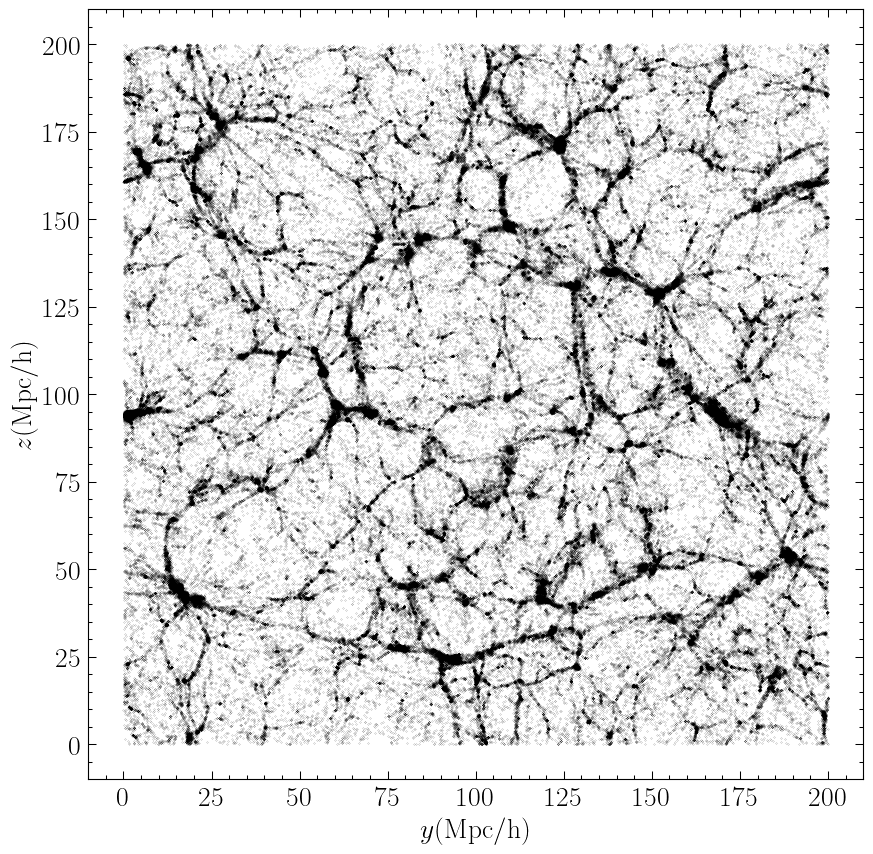

In [7]:
xmax = 1  # slab thickness, Mpc/h — keep only a thin slice in x for a 2D view
ind = np.where(Pos[:, 0] < xmax)[0]

fig, ax = plt.subplots(1, 1, figsize=(10, 10))
ax.scatter(Pos[ind, 1], Pos[ind, 2], s=0.01, color="k")
ax.set_xlabel(r"$y (\rm{Mpc}/h)$")
ax.set_ylabel(r"$z (\rm{Mpc}/h)$")


## 5. Halo catalog

Halos are gravitationally bound clumps of dark matter identified in the simulation
(dark matter halos are where galaxies form). Sahyadri distributes halo catalogs as
compressed FITS tables with several flavors (`basic` / `extended` / `vahc` / `tens`)
containing different sets of derived quantities — see the column documentation on
the data-products page. Here we use the `basic` catalog, which includes position,
virial mass/radius, and linear bias.

In [8]:
from astropy.table import Table

def load_halo_catalog(filename):
    """Load a Sahyadri halo catalog (basic / extended / vahc / tens).
    Works directly on the .fits.gz file; returns an astropy Table."""
    return Table.read(filename)        # HDU 1, binary table


In [9]:
halo_file = basedir + "halos/" + sim_stem + "/r%d/" % real + "compressed/out_%d_basic.fits.gz" % snap
t = load_halo_catalog(halo_file)
print(t.colnames, len(t))  # sanity check: available columns and number of halos


['id', 'pid', 'Mvir', 'Rvir', 'rs', 'vrms', 'x', 'y', 'z', 'vx', 'vy', 'vz', 'Mvir_all', 'M200b', 'M200c', 'M500c', 'M2500c', 'T/|U|', 'Mpeak', 'Vpeak', 'b1'] 10549241


Pull out the columns we need and apply a mass cut (`Mvir > 1e12` Msun/h) so the
plot below isn't swamped by small halos, then restrict to the same thin slab used
for the DM slice plot so the two overlay correctly.

In [10]:
pos_h = np.array([t["x"], t["y"], t["z"]]).T  # halo positions, Mpc/h
b1_h = t["b1"]                                  # linear bias — used to color each halo below
M = t["Mvir"]                                   # virial mass, Msun/h
R = t["Rvir"] / 1e3                             # virial radius, kpc/h -> Mpc/h

# Keep only massive-enough halos that also fall in the same thin x-slab as the DM plot above
ind_h = np.where((M > 10**12) & (pos_h[:, 0] < xmax))[0]


### DM + halos overlay

Same DM slice as before (now faded with `alpha=0.3`), with each selected halo drawn
as a circle: position from `(y, z)`, radius scaled from `Rvir` (exaggerated ×4 so
halos are visible against the box scale), and color mapped from linear bias `b1`
via a colorbar.

(0.0, 200.0)

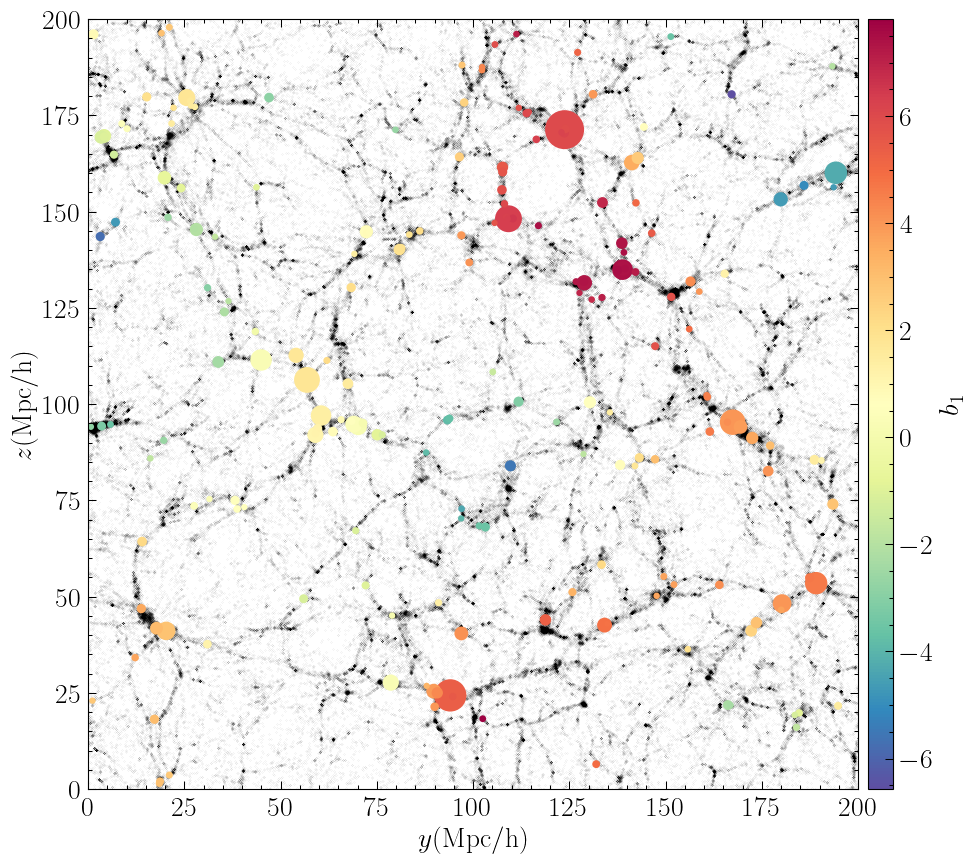

In [11]:
fig, ax = plt.subplots(1, 1, figsize=(12, 10))
ax.scatter(Pos[ind, 1], Pos[ind, 2], s=0.01, color="k", alpha=0.3)
cmap = cm.Spectral_r

norm = colors.Normalize(vmin=b1_h[ind_h].min(), vmax=b1_h[ind_h].max())
for xi, yi, ai, ri in zip(pos_h[ind_h, 1], pos_h[ind_h, 2], b1_h[ind_h], 4 * R[ind_h]):
    circle = Circle((xi, yi), ri,
                     facecolor=cmap(norm(ai)),
                     edgecolor='none')
    ax.add_patch(circle)

sm = ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])  # needed for older versions of matplotlib
cbar = plt.colorbar(sm, ax=ax, aspect=30, pad=0.01)
cbar.set_label(r"$b_1$")

ax.set_xlabel(r"$y (\rm{Mpc}/h)$")
ax.set_ylabel(r"$z (\rm{Mpc}/h)$")
ax.set_aspect(1)
ax.set_xlim(0, lbox)
ax.set_ylim(0, lbox)


## Next steps

- Browse and download full-resolution snapshots and halo catalogs at
  [sahyadri.tifr.res.in/downloads.html](https://sahyadri.tifr.res.in/downloads.html).
- See the column definitions for each halo catalog flavor (`basic` / `extended` /
  `vahc` / `tens`) on the same page.
- Questions or issues? See the contact page at
  [sahyadri.tifr.res.in](https://sahyadri.tifr.res.in/contact.html).